# Part 2 — Attention, Masks, and Training Objectives

**Guiding question:** How does one attention operation support two different ways of training a language model?

**Purpose:** compute attention once on a small example, then study the **mask** — the table that says which positions each token may read. You will map the causal mask to **autoregressive (AR)** training and the full mask to **masked language modelling (MLM)**, train one tiny model under each objective, and turn a self-attention output into a real prediction.

**Runtime:** about 30 minutes. **Prerequisite:** vectors can represent tokens; matrix multiplication forms dot products. **Roadmap:** weighted average → attention recipe → self-attention → mask patterns → AR and MLM objectives → train both → from attention to a prediction → leak test → pretrained GPT-2 and DistilBERT.

**Convention:** heat-map rows are **queries** (the position doing the reading) and columns are **keys** (the positions being read). In our masks, `True = allowed`. The toy corpus is fictional and the toy model is a classroom example. Run from top to bottom.

## 0. Setup

A **tensor** is a multidimensional numerical array. Everything runs on CPU with fixed seeds, so your numbers match the ones discussed in the text. [PyTorch tensor documentation](https://pytorch.org/docs/stable/tensors.html) describes the array operations used below.

In [1]:
import math, random, sys
import torch, torch.nn as nn, numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from matplotlib.patches import FancyBboxPatch, Rectangle
from matplotlib.colors import ListedColormap

torch.manual_seed(42); random.seed(42)
DTYPE = torch.float64
sns.set_theme(style='white')
plt.rcParams['figure.dpi'] = 130
BLUE, ORANGE, GREEN, VERMILION, GREY = '#0072B2', '#E69F00', '#009E73', '#D55E00', '#B8C2CC'
MASK_CMAP = ListedColormap(['#F3D9CC', GREEN])        # blocked, allowed
print({'python': sys.version.split()[0], 'torch': torch.__version__, 'device': 'cpu'})

{'python': '3.13.5', 'torch': '2.12.0+cu130', 'device': 'cpu'}


## 1. Start with the destination: a weighted average

Attention computes a weighted combination of **value vectors**. With weights `0.75` and `0.25`, the output receives three times as much contribution from the first value as from the second. The weights are non-negative and sum to one.

The rest of the notebook is about where those weights come from and which positions are allowed to receive any weight at all.

In [2]:
demo_values = torch.tensor([[10., 0.], [0., 20.]], dtype=DTYPE)
demo_weights = torch.tensor([.75, .25], dtype=DTYPE)
weighted_parts = demo_weights[:, None] * demo_values

display(pd.DataFrame(weighted_parts.numpy(), index=['0.75 × value 1', '0.25 × value 2'],
                     columns=['feature 1', 'feature 2']).round(2))
print('Add the rows → output:', (demo_weights @ demo_values).tolist())

,feature 1,feature 2
0.75 × value 1,7.5,0.0
0.25 × value 2,0.0,5.0


Add the rows → output: [7.5, 5.0]


### What do we see?

The output is `[7.5, 5.0]`. Attention blends several values; it does not pick one. A larger weight means a larger numerical contribution in this operation. It does not mean human-like importance or a causal explanation.

## 2. The attention recipe and matrix shapes

For queries `Q`, keys `K`, and values `V`:

1. **Match:** `QKᵀ` compares every query with every key.
2. **Scale:** divide by `√d_k` so scores stay in a moderate range.
3. **Mask:** set the score of every disallowed query–key pair to `−∞`.
4. **Normalize:** row-wise softmax turns each score row into weights summing to one. A `−∞` score becomes a weight of exactly zero.
5. **Combine:** `weights @ V` makes one output vector per query.

Step 3 is the one this notebook studies. Steps 1, 2, 4 and 5 are identical in every model you will meet.

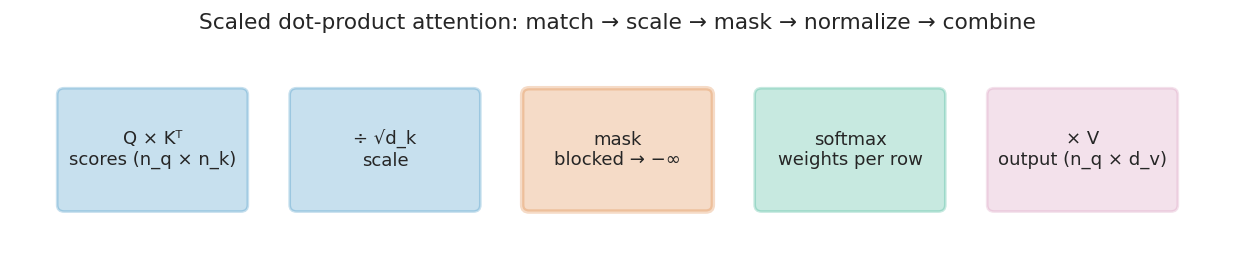

In [3]:
steps = [('Q × Kᵀ\nscores (n_q × n_k)', BLUE), ('÷ √d_k\nscale', BLUE), ('mask\nblocked → −∞', VERMILION),
         ('softmax\nweights per row', GREEN), ('× V\noutput (n_q × d_v)', '#CC79A7')]
fig, ax = plt.subplots(figsize=(12, 2.2)); ax.set_xlim(-.6, len(steps) - .4); ax.set_ylim(0, 1); ax.axis('off')
for i, (label, color) in enumerate(steps):
    ax.add_patch(FancyBboxPatch((i - .38, .25), .76, .5, boxstyle='round,pad=.03', facecolor=color, alpha=.22,
                                edgecolor=color, linewidth=2.5 if 'mask' in label else 1.5))
    ax.text(i, .5, label, ha='center', va='center', fontsize=10)
    if i < len(steps) - 1:
        ax.annotate('', xy=(i + 1 - .42, .5), xytext=(i + .42, .5), arrowprops={'arrowstyle': '->', 'lw': 1.8})
ax.set_title('Scaled dot-product attention: match → scale → mask → normalize → combine', pad=6)
plt.show()

## 3. One function, one example you can check by hand

The function below is the whole recipe. It rejects a mask that blocks every key for some query, because softmax would have no valid option.

The example has two tokens. The first query aligns with the first key and the second query with the second key.

**Look for:** each weight row sums to one, and the output mixes both value rows.

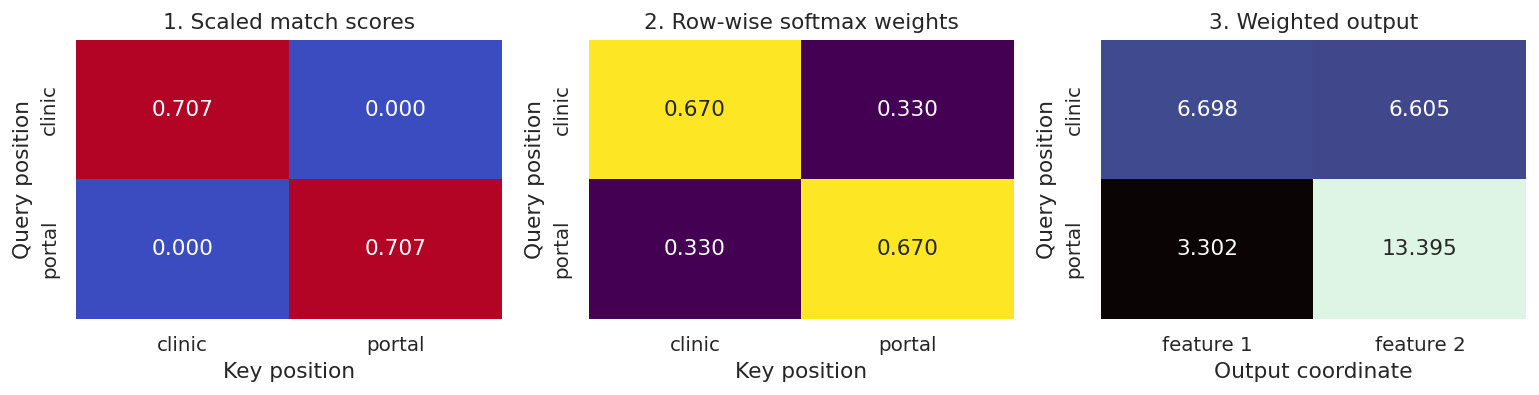

Weight row sums: [1.0, 1.0]


In [4]:
def scaled_dot_product_attention_from_scratch(query, key, value, allowed_mask=None):
    if query.shape[-1] != key.shape[-1]: raise ValueError('Query/key dimensions must match.')
    if key.shape[-2] != value.shape[-2]: raise ValueError('Key/value sequence lengths must match.')
    scores = query @ key.transpose(-2, -1) / math.sqrt(query.shape[-1])
    if allowed_mask is not None:
        if torch.any(~allowed_mask.any(dim=-1)): raise ValueError('Every query row needs an allowed key.')
        scores = scores.masked_fill(~allowed_mask, -torch.inf)
    weights = torch.softmax(scores, dim=-1)
    return weights @ value, weights, scores

query = torch.tensor([[1., 0.], [0., 1.]], dtype=DTYPE)
key   = torch.tensor([[1., 0.], [0., 1.]], dtype=DTYPE)
value = torch.tensor([[10., 0.], [0., 20.]], dtype=DTYPE)
labels = ['clinic', 'portal']
output, weights, scores = scaled_dot_product_attention_from_scratch(query, key, value)

# The explicit arithmetic agrees with PyTorch's optimized implementation.
official = torch.nn.functional.scaled_dot_product_attention(query[None, None], key[None, None], value[None, None])[0, 0]
torch.testing.assert_close(output, official, rtol=1e-6, atol=1e-7)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.2))
for ax, data, title, cmap, xl in zip(axes, [scores, weights, output],
        ['1. Scaled match scores', '2. Row-wise softmax weights', '3. Weighted output'],
        ['coolwarm', 'viridis', 'mako'], [labels, labels, ['feature 1', 'feature 2']]):
    sns.heatmap(data.numpy(), annot=True, fmt='.3f', xticklabels=xl, yticklabels=labels, cmap=cmap, ax=ax, cbar=False)
    ax.set(title=title, ylabel='Query position', xlabel='Output coordinate' if title.startswith('3') else 'Key position')
plt.tight_layout(); plt.show()
print('Weight row sums:', weights.sum(-1).tolist())

### Read one row slowly

For query `clinic`, the scaled scores are `[0.707, 0.000]`. Softmax converts them to `[0.670, 0.330]`. The output is `0.670 × [10, 0] + 0.330 × [0, 20] = [6.70, 6.60]`.

The second coordinate is large even though its weight is small, because the second value contains `20`. **Weights and values both matter.**

The `assert_close` line confirms that our five-line function matches `torch.nn.functional.scaled_dot_product_attention`. That is all the arithmetic there is. Everything that follows changes what goes *into* this function.

## 4. Self-attention: Q, K and V come from one sequence

In **self-attention**, one input matrix `X` (one row per token) is projected three ways: `Q = XW_Q`, `K = XW_K`, `V = XW_V`. Every token is a query, and every token is also a key and a value.

In **cross-attention**, queries come from one sequence and keys and values from another, such as a decoder reading an encoder's output.

**Look for:** the weight matrix is square — one row and one column per token.

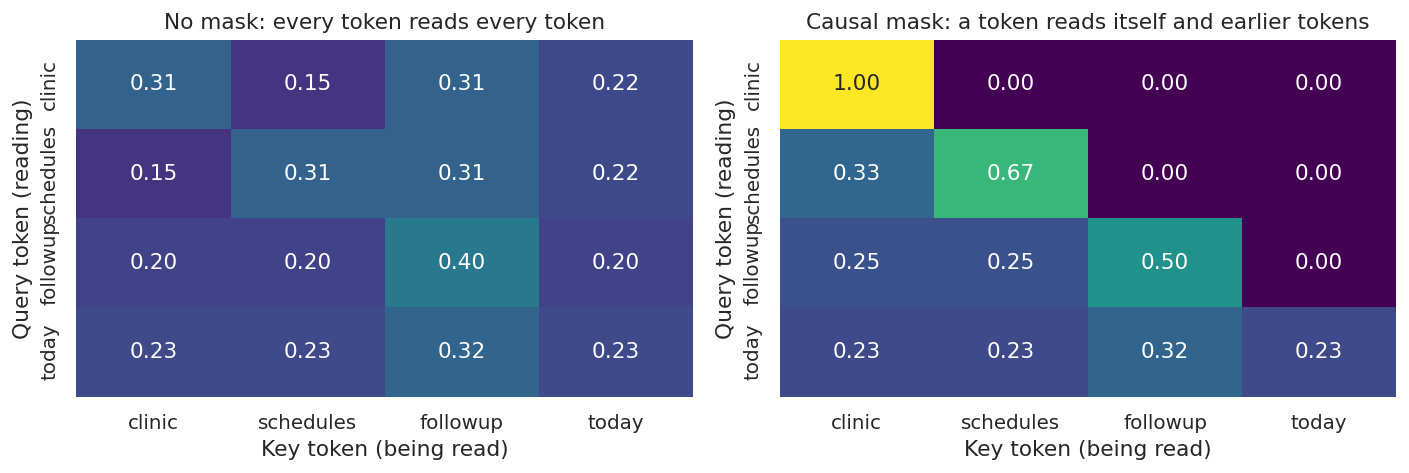

Row sums, no mask    : [1.0, 1.0, 1.0, 1.0]
Row sums, causal mask: [1.0, 1.0, 1.0, 1.0]


In [5]:
tokens = ['clinic', 'schedules', 'followup', 'today']
X = torch.tensor([[1., 0., 0.], [0., 1., 0.], [1., 1., 0.], [0., 0., 1.]], dtype=DTYPE)
W_Q = torch.tensor([[1., 0.], [0., 1.], [.5, .5]], dtype=DTYPE); W_K = W_Q.clone()
W_V = torch.tensor([[1., 0.], [0., 1.], [1., 1.]], dtype=DTYPE)
Q, K, V = X @ W_Q, X @ W_K, X @ W_V
self_output, self_weights, _ = scaled_dot_product_attention_from_scratch(Q, K, V)

causal_4 = torch.tril(torch.ones(4, 4, dtype=torch.bool))
_, causal_weights, _ = scaled_dot_product_attention_from_scratch(Q, K, V, causal_4)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for ax, w, title in zip(axes, [self_weights, causal_weights],
                        ['No mask: every token reads every token', 'Causal mask: a token reads itself and earlier tokens']):
    sns.heatmap(w.numpy(), annot=True, fmt='.2f', xticklabels=tokens, yticklabels=tokens, cmap='viridis',
                vmin=0, vmax=1, ax=ax, cbar=False)
    ax.set(title=title, xlabel='Key token (being read)', ylabel='Query token (reading)')
plt.tight_layout(); plt.show()
print('Row sums, no mask    :', [round(v, 6) for v in self_weights.sum(-1).tolist()])
print('Row sums, causal mask:', [round(v, 6) for v in causal_weights.sum(-1).tolist()])

### What do we see?

Both matrices use the same `Q`, `K` and `V`. The mask is the only difference.

Under the causal mask the upper triangle is exactly zero, and each row still sums to one: the weight that would have gone to later tokens is redistributed over the allowed ones. `clinic` can read only itself, so its row is `[1, 0, 0, 0]`.

Masking happens *before* softmax. It changes what information is available to a position. It is not a display filter applied afterwards.

## 5. A gallery of mask patterns

A mask is a Boolean table with one row per query and one column per key. Different model families are, to a large extent, different choices of this table.

| Pattern | Rule | Where it is used |
|---|---|---|
| Bidirectional (full) | every token reads every token | BERT-style encoders, embedding models |
| Causal | read yourself and earlier tokens | GPT-style decoders, all chat models |
| Padding | nobody reads `[PAD]` filler | batches of unequal-length texts |
| Causal + padding | both rules at once | decoder training in batches |
| Prefix | the prompt is read both ways; the continuation is causal | encoder–decoder style models such as T5 |
| Sliding window | read only the last `w` tokens | long-context models, to cut the `n²` cost |

**Look for:** which cells are green in each panel, and the row for the token `cough`.

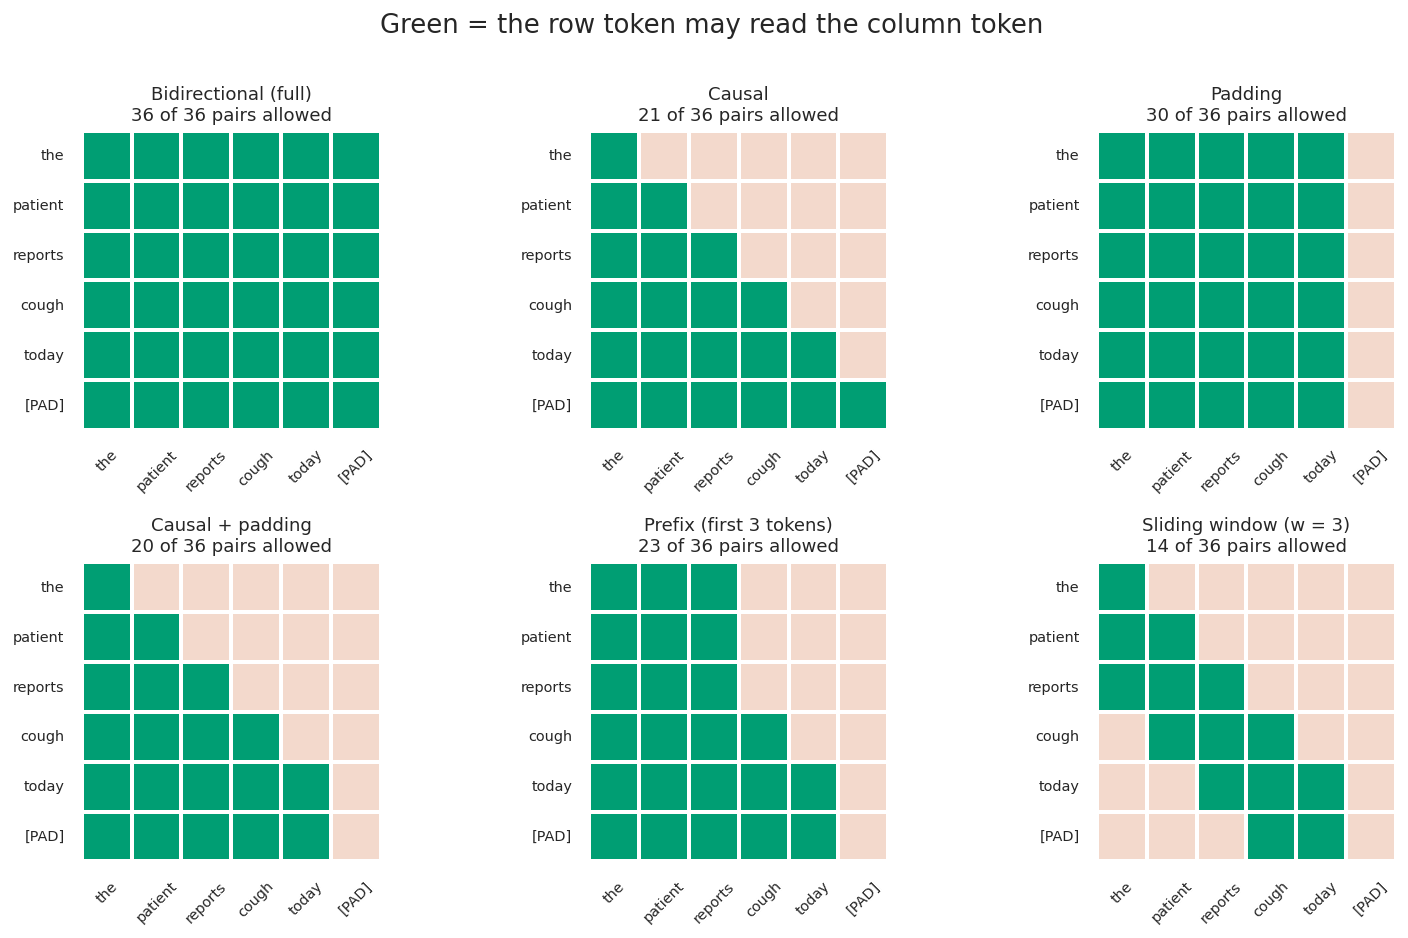

,"""cough"" may read"
Bidirectional (full),"the, patient, reports, cough, today, [PAD]"
Causal,"the, patient, reports, cough"
Padding,"the, patient, reports, cough, today"
Causal + padding,"the, patient, reports, cough"
Prefix (first 3 tokens),"the, patient, reports, cough"
Sliding window (w = 3),"patient, reports, cough"


In [6]:
sentence = ['the', 'patient', 'reports', 'cough', 'today', '[PAD]']
n = len(sentence)
full = torch.ones(n, n, dtype=torch.bool)
causal = torch.tril(full)
not_pad = torch.tensor([t != '[PAD]' for t in sentence])
padding = full & not_pad[None, :]
prefix_len = 3                                         # "the patient reports" is the prompt
prefix = causal.clone(); prefix[:prefix_len, :prefix_len] = True
window = 3
idx = torch.arange(n)
sliding = causal & (idx[:, None] - idx[None, :] < window)

patterns = [('Bidirectional (full)', full), ('Causal', causal), ('Padding', padding),
            ('Causal + padding', causal & padding), (f'Prefix (first {prefix_len} tokens)', prefix & padding),
            (f'Sliding window (w = {window})', sliding & padding)]
fig, axes = plt.subplots(2, 3, figsize=(12, 7.2))
for ax, (title, mask) in zip(axes.ravel(), patterns):
    sns.heatmap(mask.numpy().astype(int), cmap=MASK_CMAP, vmin=0, vmax=1, cbar=False, linewidths=1.2, linecolor='white',
                xticklabels=sentence, yticklabels=sentence, ax=ax, square=True)
    ax.set_title(f'{title}\n{int(mask.sum())} of {n*n} pairs allowed', fontsize=10)
    ax.tick_params(axis='x', rotation=45, labelsize=8); ax.tick_params(axis='y', rotation=0, labelsize=8)
fig.suptitle('Green = the row token may read the column token', y=1.0)
plt.tight_layout(); plt.show()

display(pd.DataFrame({title: [', '.join(t for t, ok in zip(sentence, mask[3]) if ok)] for title, mask in patterns},
                     index=['"cough" may read']).T)

### What do we see?

Under the full mask, `cough` reads the whole sentence, including `today`, which comes after it. Under the causal mask it reads only `the patient reports cough`.

The padding mask removes a **column**: no token reads `[PAD]`. The `[PAD]` row is still computed, and its output is simply ignored when the loss is calculated.

The sliding window allows the fewest pairs. That is its purpose: full attention on `n` tokens costs `n²` comparisons, and a window of width `w` costs about `n × w`.

## 6. Two training objectives, two masks

A language model learns from raw text with no human labels. The text supplies its own answers. There are two standard ways to set that up.

**Autoregressive (AR) — predict the next token.** The input is the sentence; the target at each position is the token that follows it. Every position is a training example. The causal mask is required: without it, position 3 could read position 4, which *is* its answer.

**Masked language modelling (MLM) — fill in the blank.** A random ~15% of tokens are replaced with a special `[MASK]` token. The target is the original token, and only the masked positions are scored. The attention mask is **full**, because the clues can be on either side of the blank.

The word *mask* means two different things here. The **attention mask** is the Boolean table from section 5. The **`[MASK]` token** is a change to the *input*. MLM uses a `[MASK]` token together with a full attention mask.

**Look for:** how many positions produce a training signal under each objective.

AUTOREGRESSIVE: one target per position


,position,model input,may read,target (next token)
0,0,the,the,patient
1,1,patient,the patient,reports
2,2,reports,the patient reports,cough
3,3,cough,the patient reports cough,so
4,4,so,the patient reports cough so,the
5,5,the,the patient reports cough so the,nurse
6,6,nurse,the patient reports cough so the nurse,orders
7,7,orders,the patient reports cough so the nurse orders,a
8,8,a,the patient reports cough so the nurse orders a,chest
9,9,chest,the patient reports cough so the nurse orders ...,xray


MASKED LANGUAGE MODELLING: targets only at [MASK]


,position,model input,may read,target
0,0,the,the whole corrupted sentence,— not scored —
1,1,patient,the whole corrupted sentence,— not scored —
2,2,reports,the whole corrupted sentence,— not scored —
3,3,[MASK],the whole corrupted sentence,cough
4,4,so,the whole corrupted sentence,— not scored —
5,5,the,the whole corrupted sentence,— not scored —
6,6,nurse,the whole corrupted sentence,— not scored —
7,7,orders,the whole corrupted sentence,— not scored —
8,8,a,the whole corrupted sentence,— not scored —
9,9,chest,the whole corrupted sentence,— not scored —


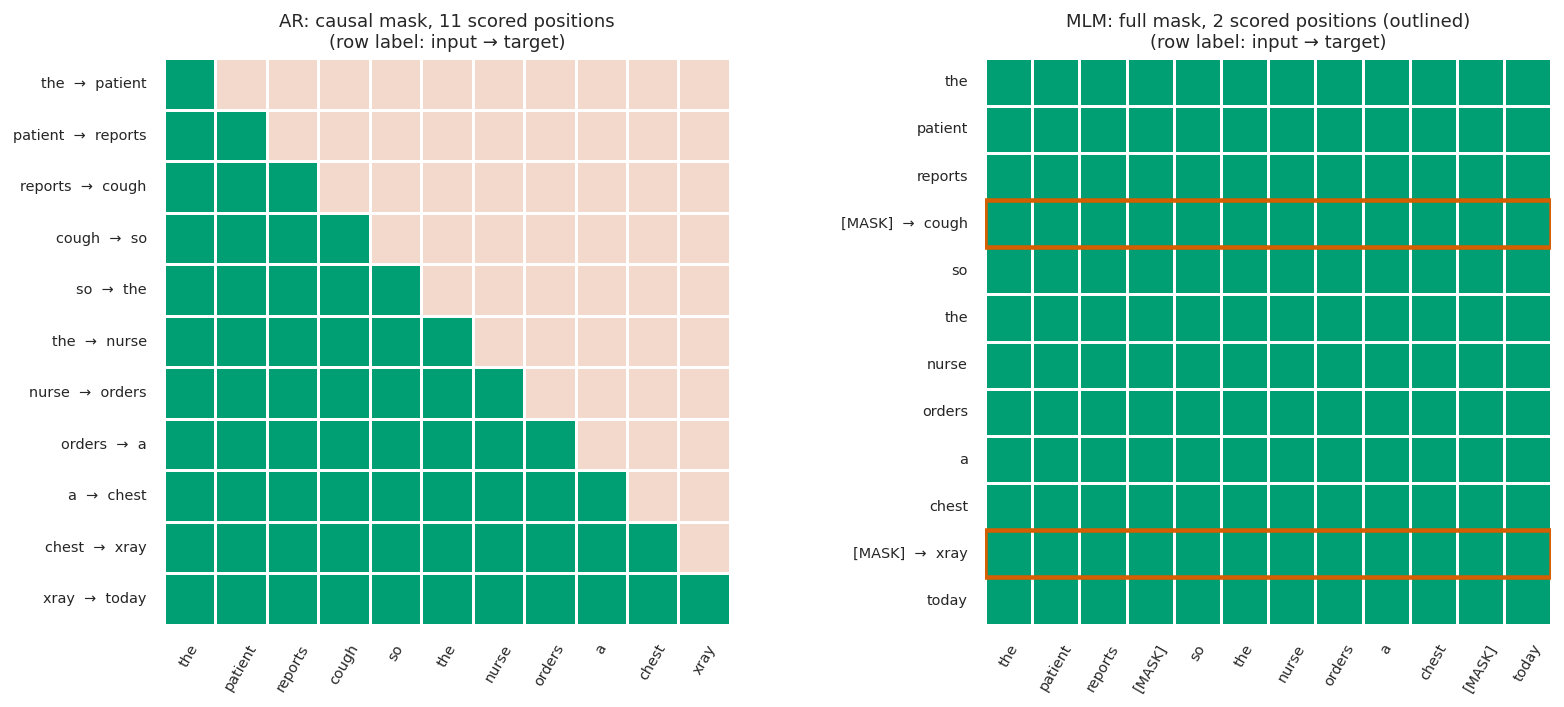

In [7]:
example = 'the patient reports cough so the nurse orders a chest xray today'.split()
T_ex = len(example)
masked_positions = [3, 10]                              # chosen by hand here; chosen at random in training

ar_table = pd.DataFrame({'position': range(T_ex - 1), 'model input': example[:-1],
                         'may read': [' '.join(example[:i + 1]) for i in range(T_ex - 1)],
                         'target (next token)': example[1:]})
mlm_input = [('[MASK]' if i in masked_positions else t) for i, t in enumerate(example)]
mlm_table = pd.DataFrame({'position': range(T_ex), 'model input': mlm_input,
                          'may read': 'the whole corrupted sentence',
                          'target': [t if i in masked_positions else '— not scored —' for i, t in enumerate(example)]})
print('AUTOREGRESSIVE: one target per position'); display(ar_table)
print('MASKED LANGUAGE MODELLING: targets only at [MASK]'); display(mlm_table)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.6))
ar_mask = torch.tril(torch.ones(T_ex - 1, T_ex - 1, dtype=torch.bool))
sns.heatmap(ar_mask.numpy().astype(int), cmap=MASK_CMAP, cbar=False, linewidths=.8, linecolor='white', square=True,
            xticklabels=example[:-1], yticklabels=[f'{a}  →  {b}' for a, b in zip(example[:-1], example[1:])], ax=axes[0])
axes[0].set_title(f'AR: causal mask, {T_ex - 1} scored positions\n(row label: input → target)', fontsize=10)
mlm_mask = torch.ones(T_ex, T_ex, dtype=torch.bool)
sns.heatmap(mlm_mask.numpy().astype(int), cmap=MASK_CMAP, vmin=0, vmax=1, cbar=False, linewidths=.8, linecolor='white', square=True,
            xticklabels=mlm_input, yticklabels=[f'[MASK]  →  {example[i]}' if i in masked_positions else t
                                                for i, t in enumerate(mlm_input)], ax=axes[1])
for p in masked_positions:
    axes[1].add_patch(Rectangle((0, p), T_ex, 1, fill=False, edgecolor=VERMILION, linewidth=2.5))
axes[1].set_title(f'MLM: full mask, {len(masked_positions)} scored positions (outlined)\n(row label: input → target)', fontsize=10)
for ax in axes:
    ax.tick_params(axis='x', rotation=60, labelsize=8); ax.tick_params(axis='y', rotation=0, labelsize=8)
plt.tight_layout(); plt.show()

### What do we see?

AR scores 11 of the 11 input positions. MLM scores 2 of 12. AR extracts more training signal from each sentence, which is one reason the largest generative models are trained this way.

MLM gets something in exchange. The row for the first `[MASK]` is fully green: the model may read `chest xray` on the **right** of the blank. The AR row for the same position stops at `reports`.

That difference decides what each model is good at. AR models *generate*, one token after another. MLM models *represent*: they build a reading of a whole passage, which suits classification, entity recognition, and the embedding models used for retrieval in Part 3.

## 7. Train one tiny model under each objective

To see the consequences, we train the same small architecture twice on the same fictional corpus. Only the mask and the targets differ.

The corpus is built from a template in which each symptom determines the test that is ordered:

`the patient reports <symptom> so the <who> orders a <test> <when>`

The model is a single self-attention head that calls **our own function from section 3**, followed by a small feed-forward layer and a **prediction head**. The head is a linear layer that turns a position's output vector into one score per vocabulary word.

This is a toy with a 26-word vocabulary and 36 sentences. It shows the mechanism. It is not a language model and knows nothing about medicine.

**Look for:** both losses fall, and training takes a few seconds.

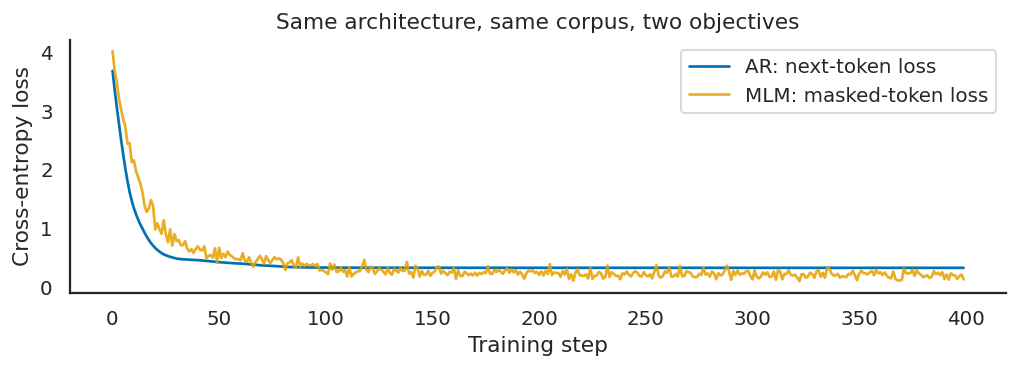

{'sentences': 36, 'tokens per sentence': 12, 'vocabulary': 26, 'final AR loss': 0.326, 'final MLM loss': 0.13}


In [8]:
PAIRS = [('cough', 'chest xray'), ('fever', 'blood test'), ('rash', 'skin swab'), ('dizziness', 'heart tracing')]
WHO, WHEN = ['nurse', 'doctor', 'clinic'], ['today', 'tomorrow', 'monday']
corpus = [f'the patient reports {s} so the {who} orders a {test} {when}'.split()
          for s, test in PAIRS for who in WHO for when in WHEN]
vocab = ['[PAD]', '[MASK]'] + sorted({w for sent in corpus for w in sent})
token_id = {w: i for i, w in enumerate(vocab)}
DATA = torch.tensor([[token_id[w] for w in sent] for sent in corpus])
N_SENT, T, VOCAB = DATA.shape[0], DATA.shape[1], len(vocab)
CAUSAL, FULL = torch.tril(torch.ones(T, T, dtype=torch.bool)), torch.ones(T, T, dtype=torch.bool)

class TinyAttentionLM(nn.Module):
    # token + position embeddings -> one self-attention head -> feed-forward -> prediction head
    def __init__(self, vocab_size, max_len, d=32):
        super().__init__()
        self.tok, self.pos = nn.Embedding(vocab_size, d), nn.Embedding(max_len, d)
        self.W_Q, self.W_K, self.W_V = (nn.Linear(d, d, bias=False) for _ in range(3))
        self.ff = nn.Sequential(nn.Linear(d, 64), nn.ReLU(), nn.Linear(64, d))
        self.head = nn.Linear(d, vocab_size)
    def forward(self, ids, allowed_mask):
        x = self.tok(ids) + self.pos(torch.arange(ids.shape[1]))
        attended, weights, _ = scaled_dot_product_attention_from_scratch(self.W_Q(x), self.W_K(x), self.W_V(x), allowed_mask)
        h = x + attended
        h = h + self.ff(h)
        return self.head(h), weights                     # logits: one score per vocabulary word, per position

def train(objective, steps=400):
    torch.manual_seed(0)
    model = TinyAttentionLM(VOCAB, T); optimizer = torch.optim.Adam(model.parameters(), lr=3e-3)
    rng = torch.Generator().manual_seed(0); history = []
    for _ in range(steps):
        if objective == 'AR':                            # input: all but the last token; target: shifted by one
            logits, _ = model(DATA[:, :-1], CAUSAL[:-1, :-1])
            loss = nn.functional.cross_entropy(logits.reshape(-1, VOCAB), DATA[:, 1:].reshape(-1))
        else:                                            # corrupt ~15% of tokens; score only those positions
            chosen = torch.rand(DATA.shape, generator=rng) < 0.15
            chosen[torch.arange(N_SENT), torch.randint(0, T, (N_SENT,), generator=rng)] = True
            logits, _ = model(DATA.masked_fill(chosen, token_id['[MASK]']), FULL)
            loss = nn.functional.cross_entropy(logits.reshape(-1, VOCAB), DATA.masked_fill(~chosen, -100).reshape(-1),
                                               ignore_index=-100)
        optimizer.zero_grad(); loss.backward(); optimizer.step(); history.append(loss.item())
    return model.eval(), history

ar_model, ar_history = train('AR')
mlm_model, mlm_history = train('MLM')

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(ar_history, color=BLUE, label='AR: next-token loss'); ax.plot(mlm_history, color=ORANGE, label='MLM: masked-token loss', alpha=.85)
ax.set(xlabel='Training step', ylabel='Cross-entropy loss', title='Same architecture, same corpus, two objectives'); ax.legend(); sns.despine()
plt.tight_layout(); plt.show()
print({'sentences': N_SENT, 'tokens per sentence': T, 'vocabulary': VOCAB,
       'final AR loss': round(ar_history[-1], 3), 'final MLM loss': round(mlm_history[-1], 3)})

### What do we see?

Both losses fall quickly. The AR loss settles above zero, and that is correct rather than a failure: some next tokens cannot be known from the left context. After `reports`, four symptoms are equally likely, so the best possible model still spreads its probability across them.

The MLM loss is noisier because a different random set of positions is masked at every step.

## 8. From a self-attention output to a prediction

A prediction at one position is made in three steps:

1. **Attend.** The position's query is matched against the keys it is allowed to read, giving one row of attention weights.
2. **Combine.** Those weights blend the value vectors into a single output vector for that position.
3. **Predict.** The head turns the output vector into one score per vocabulary word (the **logits**), and softmax turns the scores into probabilities.

For AR, the output at position *i* predicts token *i + 1*. For MLM, the output at a `[MASK]` position predicts the token that was hidden there.

**Look for:** in each left-hand panel, which tokens the predicting position read. In each right-hand panel, what it predicted.

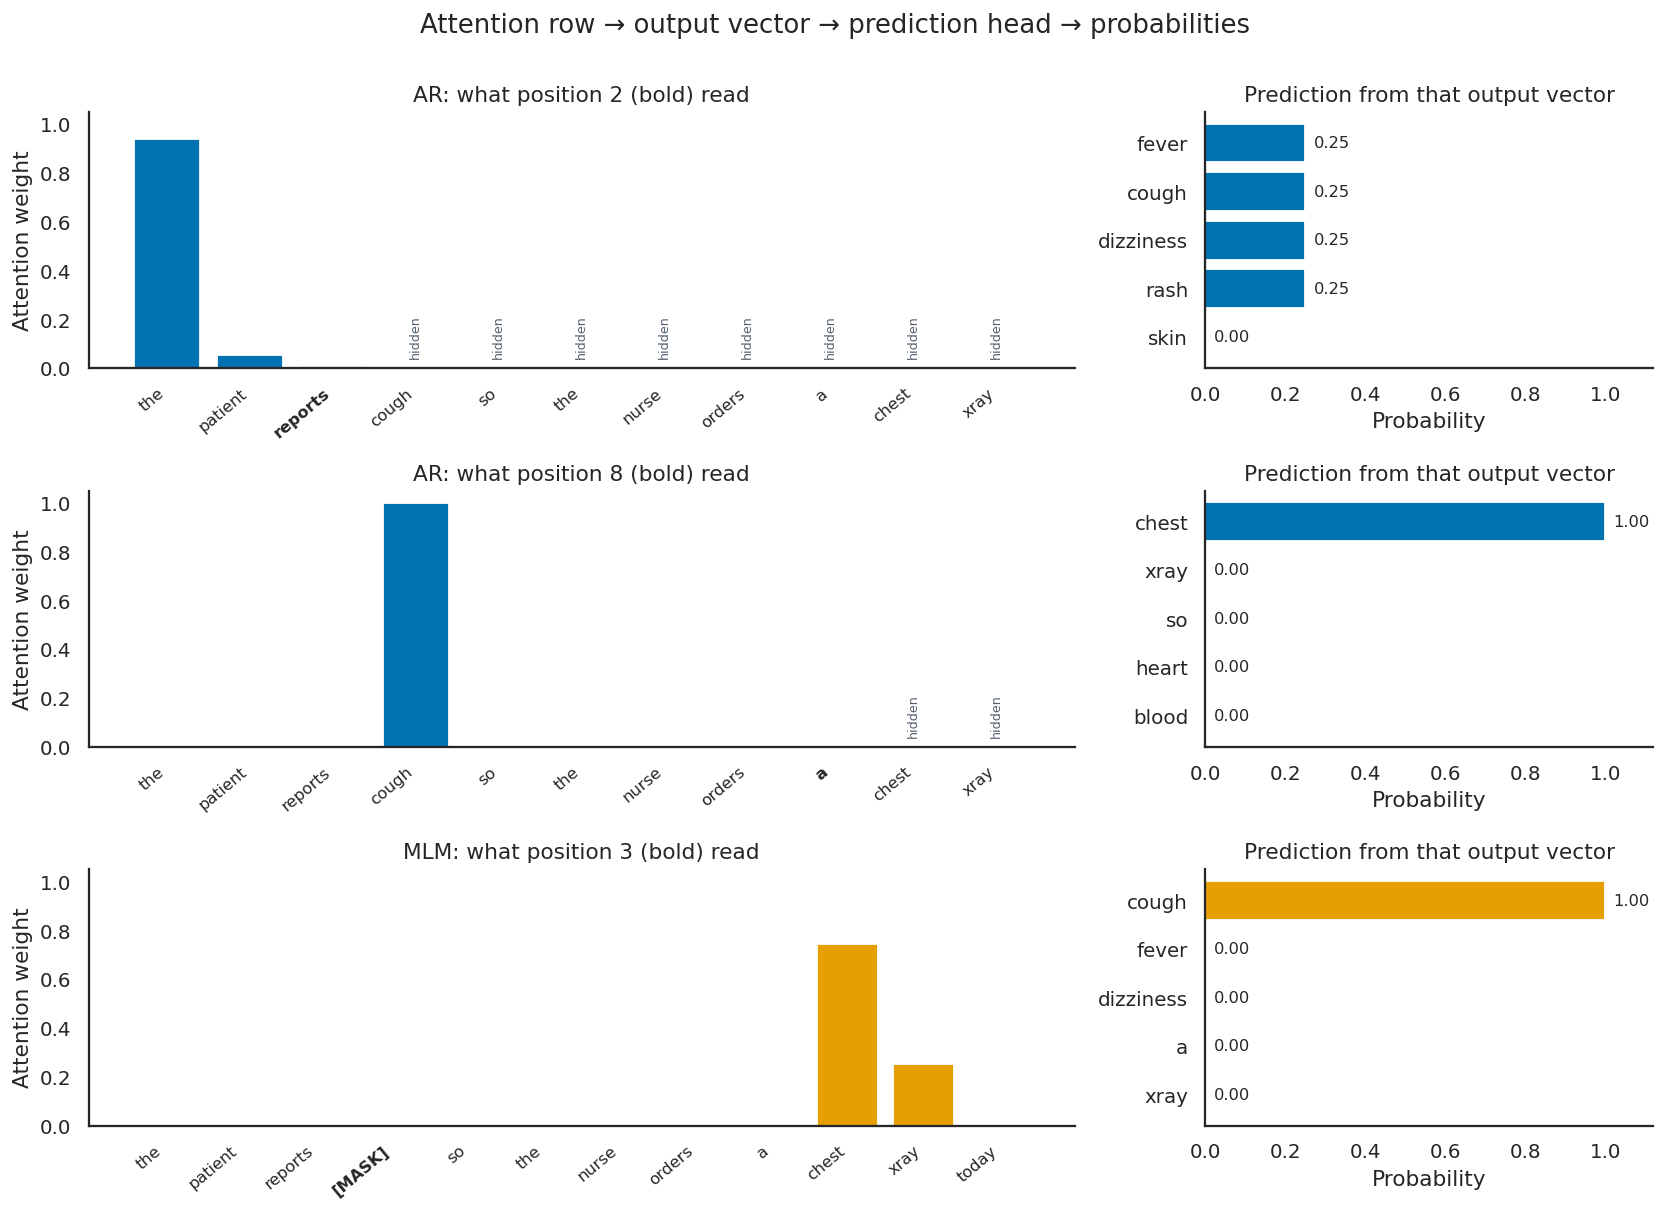

In [9]:
def encode(words): return torch.tensor([[token_id[w] for w in words]])

def predict(model, words, position, allowed_mask, k=5):
    with torch.no_grad():
        logits, weights = model(encode(words), allowed_mask[:len(words), :len(words)])
    probs = torch.softmax(logits[0, position], -1)
    top_p, top_i = probs.topk(k)
    return weights[0, position].numpy(), [vocab[i] for i in top_i], top_p.numpy()

def prediction_figure(rows, suptitle):
    fig, axes = plt.subplots(len(rows), 2, figsize=(13, 3.1 * len(rows)), gridspec_kw={'width_ratios': [2.2, 1]})
    axes = np.atleast_2d(axes)
    for (label, model, words, position, mask, colour), (ax_w, ax_p) in zip(rows, axes):
        w, top_words, top_p = predict(model, words, position, mask)
        visible = mask[position, :len(words)].numpy()
        ax_w.bar(range(len(words)), w, color=[colour if ok else GREY for ok in visible])
        ax_w.set_xticks(range(len(words))); ax_w.set_xticklabels(words, rotation=40, ha='right', fontsize=9)
        ax_w.get_xticklabels()[position].set_fontweight('bold'); ax_w.set_ylim(0, 1.05)
        for j, ok in enumerate(visible):
            if not ok: ax_w.text(j, .04, 'hidden', rotation=90, ha='center', va='bottom', fontsize=7, color='#55616D')
        ax_w.set(ylabel='Attention weight', title=f'{label}: what position {position} (bold) read')
        ax_p.barh(top_words[::-1], top_p[::-1], color=colour); ax_p.set_xlim(0, 1.12)
        for y, p in enumerate(top_p[::-1]): ax_p.text(p + .02, y, f'{p:.2f}', va='center', fontsize=9)
        ax_p.set(xlabel='Probability', title='Prediction from that output vector')
    fig.suptitle(suptitle, y=1.0); sns.despine(); plt.tight_layout(); plt.show()

sent = 'the patient reports cough so the nurse orders a chest xray today'.split()
masked_sent = [('[MASK]' if w == 'cough' else w) for w in sent]
prediction_figure([
    ('AR', ar_model, sent[:-1], 2, CAUSAL, BLUE),          # after "reports": which symptom comes next?
    ('AR', ar_model, sent[:-1], 8, CAUSAL, BLUE),          # after "a": which test comes next?
    ('MLM', mlm_model, masked_sent, 3, FULL, ORANGE),      # the symptom is hidden; the test is visible
], 'Attention row → output vector → prediction head → probabilities')

### What do we see?

**Row 1 — AR after `reports`.** The model splits its probability evenly across the four symptoms, 0.25 each. Nothing to the left tells it which one is coming, and the grey bars show that everything to the right is hidden. This is the honest answer.

**Row 2 — AR after `a`.** Now the model is confident: `chest`. Look at where the attention went — almost entirely to `cough`. The model learned that the symptom determines the test, and attention is the mechanism that carries that information forward eight positions.

**Row 3 — MLM at the blank.** The symptom is hidden, and the model recovers `cough` with near certainty. Its attention goes to the **right**, to `chest` and `xray`. The AR model at this position had no access to those tokens.

The three rows use the same architecture and the same attention function. The mask decided what each position could read, and the objective decided what it was asked to predict.

### Change the right-hand context

If the MLM model really reads to the right, changing the test should change the predicted symptom while everything to the left of the blank stays the same.

**Look for:** the top prediction in each row.

In [10]:
rows = []
for symptom, test in PAIRS:
    words = f'the patient reports [MASK] so the nurse orders a {test} today'.split()
    w, top_words, top_p = predict(mlm_model, words, 3, FULL, k=2)
    _, ar_words, ar_p = predict(ar_model, words[:3], 2, CAUSAL, k=4)
    rows.append({'right-hand context': f'… orders a {test}', 'MLM top prediction': f'{top_words[0]} ({top_p[0]:.2f})',
                 'most-read token': words[int(w.argmax())],
                 'AR prediction after "reports"': ', '.join(f'{a} {b:.2f}' for a, b in zip(ar_words, ar_p))})
display(pd.DataFrame(rows))

,right-hand context,MLM top prediction,most-read token,"AR prediction after ""reports"""
0,… orders a chest xray,cough (1.00),chest,"fever 0.25, cough 0.25, dizziness 0.25, rash 0.25"
1,… orders a blood test,fever (1.00),test,"fever 0.25, cough 0.25, dizziness 0.25, rash 0.25"
2,… orders a skin swab,rash (1.00),swab,"fever 0.25, cough 0.25, dizziness 0.25, rash 0.25"
3,… orders a heart tracing,dizziness (1.00),heart,"fever 0.25, cough 0.25, dizziness 0.25, rash 0.25"


### What do we see?

The MLM prediction follows the test every time, and the most-read token is part of the test name. The AR column is identical in all four rows, because the AR model's input up to `reports` is identical in all four.

## 9. Test the mask: can information leak from the future?

A causal mask makes a guarantee: a prediction at position *i* cannot depend on any token after *i*. We can test that guarantee directly. Change two **late** tokens, `chest xray` → `blood test`, and measure how much the model's scores at the **earlier** positions move.

**Look for:** an exact zero for the AR model.

In [11]:
original = 'the patient reports cough so the nurse orders a chest xray today'.split()
altered  = 'the patient reports cough so the nurse orders a blood test today'.split()
first_changed = 9
with torch.no_grad():
    shift = {name: (model(encode(original), mask)[0] - model(encode(altered), mask)[0])[0].abs().max(-1).values.numpy()
             for name, model, mask in [('AR (causal mask)', ar_model, CAUSAL), ('MLM (full mask)', mlm_model, FULL)]}
leak = pd.DataFrame(shift, index=[f'{i}: {w}' for i, w in enumerate(original)]).round(4)
leak['position is'] = ['before the change'] * first_changed + ['changed', 'changed', 'after the change']
display(leak)
print('Largest score change BEFORE the edited tokens →',
      {name: float(values[:first_changed].max().round(6)) for name, values in shift.items()})

,AR (causal mask),MLM (full mask),position is
0: the,0.0000,0.0100,before the change
1: patient,0.0000,0.1553,before the change
2: reports,0.0000,0.0131,before the change
3: cough,0.0000,12.5229,before the change
4: so,0.0000,0.0075,before the change
5: the,0.0000,0.0138,before the change
6: nurse,0.0000,0.0022,before the change
7: orders,0.0000,0.7956,before the change
8: a,0.0000,2.7634,before the change
9: chest,17.3864,9.5166,changed


Largest score change BEFORE the edited tokens → {'AR (causal mask)': 0.0, 'MLM (full mask)': 12.522912979125977}


### What do we see?

For the AR model, every position before the edit shows a change of exactly `0.0`. The future cannot influence the past, by construction. This is what makes generation possible: the model can write token 10 without token 11 existing yet.

For the MLM model, earlier positions change by several units. That is the intended behaviour. It also means an MLM model cannot simply be run left to right to generate text: it was trained expecting to see both sides.

The same test is a useful debugging tool. If an AR model ever shows a non-zero change here, its mask is wrong and its training loss is meaningless, because it has been reading its own answers. This is the sequence-model version of the data leakage you met in Tutorial 1.

## 10. The same two objectives in real pretrained models

`distilgpt2` was trained with the AR objective and a causal mask. `distilbert-base-uncased` was trained with the MLM objective and a full mask. Both are small, run on a laptop CPU, and download once (about 600 MB in total) through the [`transformers`](https://huggingface.co/docs/transformers) library.

These are general-purpose models trained on web text and books. They are **not clinical models**, and their completions are not medical statements.

If the download is not possible, this section prints a notice and the rest of the notebook is unaffected.

**Look for:** the shape of each attention map, and whether DistilBERT's answer changes with the words to the right of the blank.

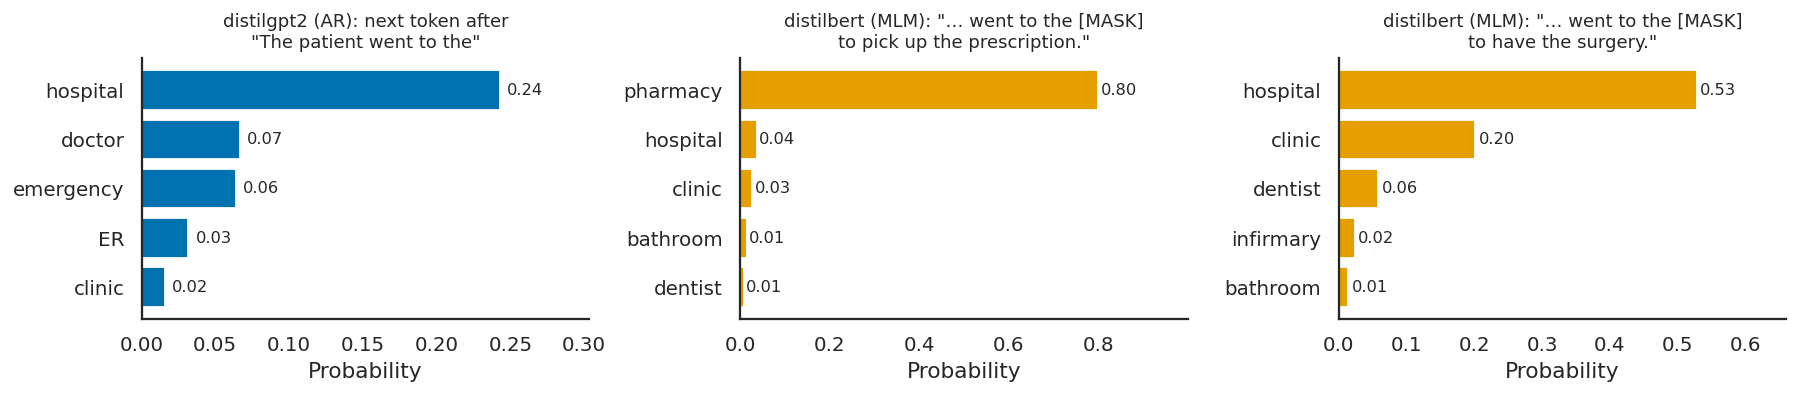

In [12]:
PRETRAINED = None
try:
    import transformers
    from transformers import AutoTokenizer, AutoModelForCausalLM, AutoModelForMaskedLM
    transformers.logging.set_verbosity_error(); transformers.logging.disable_progress_bar()
    gpt_tok = AutoTokenizer.from_pretrained('distilgpt2')
    gpt = AutoModelForCausalLM.from_pretrained('distilgpt2', attn_implementation='eager').eval()
    bert_tok = AutoTokenizer.from_pretrained('distilbert-base-uncased')
    bert = AutoModelForMaskedLM.from_pretrained('distilbert-base-uncased', attn_implementation='eager').eval()
    PRETRAINED = True
except Exception as error:
    print(f'Pretrained models unavailable ({type(error).__name__}). Skipping section 10; sections 1-9 are complete without it.')

if PRETRAINED is None:
    print('PRETRAINED is None — nothing to show.')
else:
    def gpt_next(prompt, k=5):
        enc = gpt_tok(prompt, return_tensors='pt')
        with torch.no_grad(): out = gpt(**enc, output_attentions=True)
        p, i = torch.softmax(out.logits[0, -1], -1).topk(k)
        return [gpt_tok.decode(j).strip() for j in i], p.numpy(), out.attentions, gpt_tok.convert_ids_to_tokens(enc.input_ids[0])

    def bert_fill(text, k=5):
        enc = bert_tok(text, return_tensors='pt')
        with torch.no_grad(): out = bert(**enc, output_attentions=True)
        position = int((enc.input_ids[0] == bert_tok.mask_token_id).nonzero()[0, 0])
        p, i = torch.softmax(out.logits[0, position], -1).topk(k)
        return [bert_tok.decode(j) for j in i], p.numpy(), out.attentions, bert_tok.convert_ids_to_tokens(enc.input_ids[0])

    AR_PROMPT = 'The patient went to the'
    MLM_TEXTS = ['The patient went to the [MASK] to pick up the prescription.',
                 'The patient went to the [MASK] to have the surgery.']
    gpt_words, gpt_p, gpt_att, gpt_tokens = gpt_next(AR_PROMPT)
    fills = [bert_fill(t) for t in MLM_TEXTS]

    fig, axes = plt.subplots(1, 3, figsize=(14, 3.2))
    for ax, words, p, colour, title in [(axes[0], gpt_words, gpt_p, BLUE, 'distilgpt2 (AR): next token after\n"The patient went to the"'),
                                        (axes[1], fills[0][0], fills[0][1], ORANGE, 'distilbert (MLM): "… went to the [MASK]\nto pick up the prescription."'),
                                        (axes[2], fills[1][0], fills[1][1], ORANGE, 'distilbert (MLM): "… went to the [MASK]\nto have the surgery."')]:
        ax.barh(words[::-1], p[::-1], color=colour); ax.set_title(title, fontsize=10); ax.set_xlabel('Probability')
        for y, v in enumerate(p[::-1]): ax.text(v + .005, y, f'{v:.2f}', va='center', fontsize=9)
        ax.set_xlim(0, max(p) * 1.25)
    sns.despine(); plt.tight_layout(); plt.show()

### What do we see?

`distilgpt2` reads only `The patient went to the` and spreads its probability over plausible destinations, with `hospital` first at 0.24. It behaves like the toy AR model after `reports`: the left context narrows the options and cannot settle them.

`distilbert` receives the same five words on the left of the blank, plus the rest of the sentence. With `to pick up the prescription` on the right it answers `pharmacy` at 0.80. With `to have the surgery` it answers `hospital` at 0.53. The left context is identical in both sentences, so the change comes entirely from tokens to the right of the blank.

If the download was skipped, the toy results in section 8 show the same contrast.

### The masks are visible in the attention maps

Each model has several layers, each with 12 attention heads. The maps below average the 12 heads of the first layer.

**Look for:** a triangle on the left and a filled square on the right.

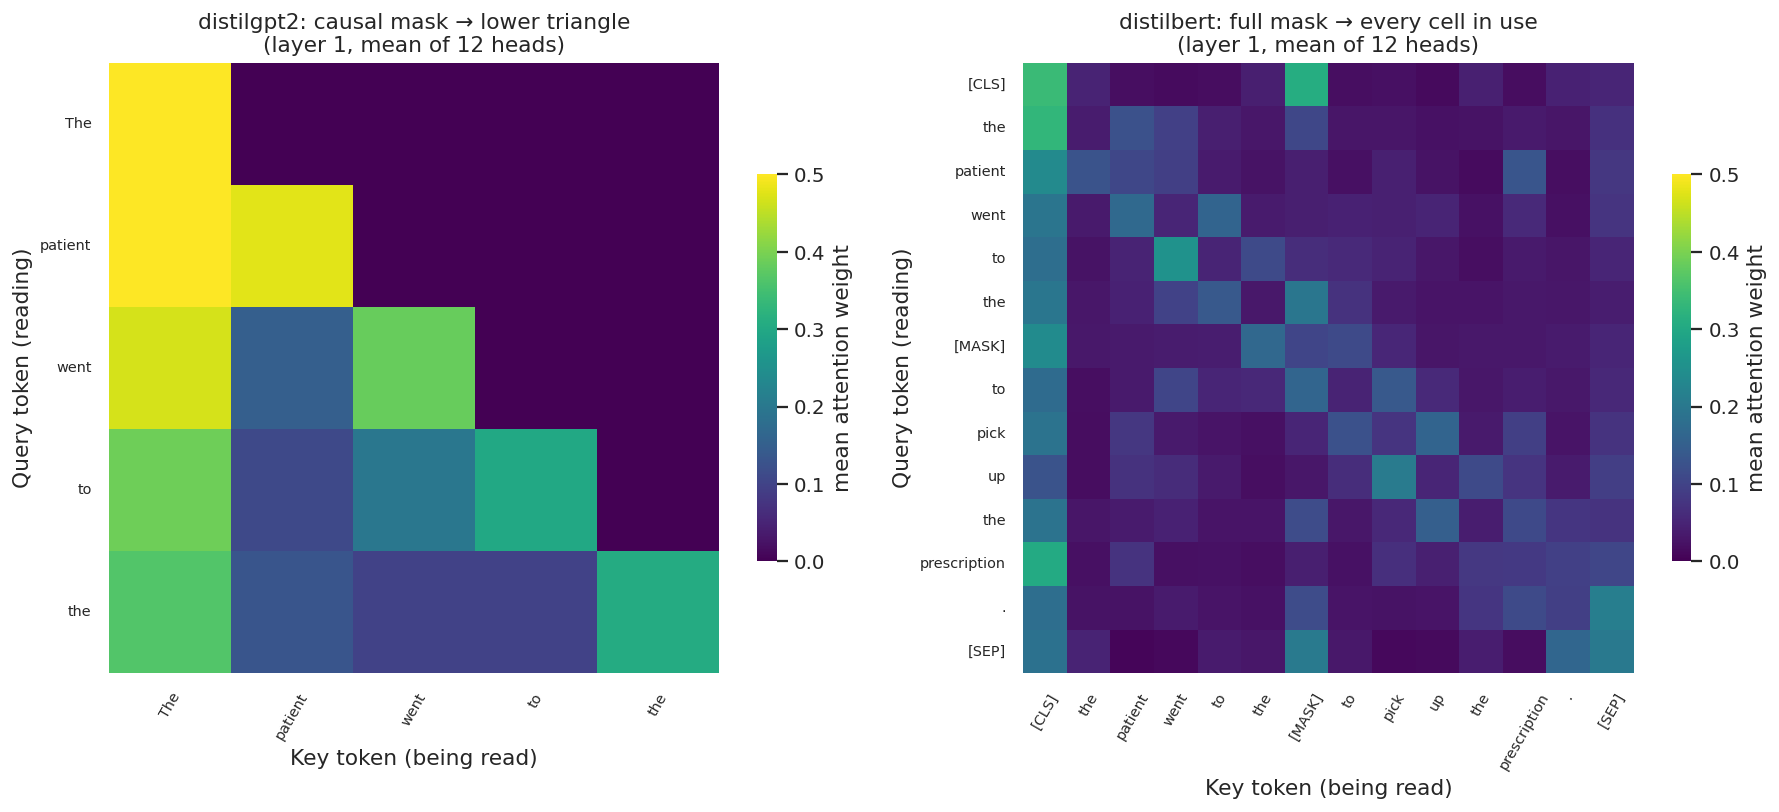

distilgpt2 — largest weight above the diagonal : 0.0
distilbert — share of weight above the diagonal: 0.382


In [13]:
if PRETRAINED is None:
    print('PRETRAINED is None — nothing to show.')
else:
    def clean(tokens): return [t.replace('Ġ', '') for t in tokens]
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    for ax, attentions, toks, title in [(axes[0], gpt_att, gpt_tokens, 'distilgpt2: causal mask → lower triangle'),
                                        (axes[1], fills[0][2], fills[0][3], 'distilbert: full mask → every cell in use')]:
        grid = attentions[0][0].mean(0).numpy()
        sns.heatmap(grid, cmap='viridis', vmin=0, vmax=.5, square=True, cbar_kws={'shrink': .6, 'label': 'mean attention weight'},
                    xticklabels=clean(toks), yticklabels=clean(toks), ax=ax)
        ax.set(title=f'{title}\n(layer 1, mean of 12 heads)', xlabel='Key token (being read)', ylabel='Query token (reading)')
        ax.tick_params(axis='x', rotation=60, labelsize=8); ax.tick_params(axis='y', rotation=0, labelsize=8)
    plt.tight_layout(); plt.show()
    upper = np.triu(gpt_att[0][0].mean(0).numpy(), k=1)
    print('distilgpt2 — largest weight above the diagonal :', float(upper.max()))
    print('distilbert — share of weight above the diagonal:', round(float(np.triu(fills[0][2][0][0].mean(0).numpy(), k=1).sum()
                                                                        / fills[0][2][0][0].mean(0).numpy().sum()), 3))

### What do we see?

The `distilgpt2` map is a lower triangle. The largest weight above the diagonal is exactly `0.0`, the same guarantee the leak test confirmed for the toy model. The bright first column is a known habit of GPT-style models: when a head has nothing specific to read, it parks its weight on the first token.

The `distilbert` map fills the whole square, and about 38% of its weight sits above the diagonal, on tokens that come later in the sentence. The `[MASK]` row reads in both directions.

These are averages over 12 heads in one layer. Individual heads look quite different from one another, and an attention map shows where weight went. It does not explain why the model produced its answer.

## 11. Try it yourself — predict before running

Make one change at a time and write down your prediction first.

1. In section 5, change `window = 3` to `window = 2`. How many pairs does the sliding-window mask allow?
2. In section 8, change the AR position from `8` to `9` (after `chest`). Which token do you expect, and where will the attention go?
3. In section 9, train the AR model with the **full** mask instead: replace `CAUSAL[:-1, :-1]` with `FULL[:-1, :-1]` inside `train`. What happens to the training loss, and what does the leak test now report? **Answer:** the loss collapses toward zero because each position reads its own answer, and the leak test turns non-zero. The low loss is worthless.
4. In section 10, write your own pair of `MLM_TEXTS` that differ only to the right of `[MASK]`.

### Learner check

- **Which mask does a chat model use while it writes a reply?** Causal. It cannot read tokens it has not produced yet.
- **An embedding model turns a whole paragraph into one vector for search. Which objective family suits it?** MLM-style, with a full mask, because every token should be read in the context of the entire passage.
- **Why does MLM score only ~15% of positions?** Unmasked positions can see their own token, so predicting them teaches nothing.

## Summary and completion checklist

**Result:** attention is one short function. A mask decides which positions each token may read. A causal mask plus next-token targets gives autoregressive training and a model that can generate. A full mask plus `[MASK]` targets gives masked language modelling and a model that reads both directions. In both cases a prediction is an attention row, a blended output vector, and a prediction head.

- [x] Traced `QKᵀ / √d_k → mask → softmax → weights @ V` on a hand-checkable example and matched PyTorch.
- [x] Compared six mask patterns on one sentence.
- [x] Mapped the causal mask to AR targets and the full mask to MLM targets.
- [x] Trained one architecture under both objectives.
- [x] Followed an attention row through the head to a probability distribution.
- [x] Verified with a leak test that the causal mask blocks the future exactly.
- [x] Saw both objectives and both mask shapes in pretrained models.

**Limits:** the toy model has one head, one layer, 36 template sentences and a 26-word vocabulary; it demonstrates a mechanism and nothing about medicine. Attention weights are computed contributions, not explanations, clinical importance, or proof of understanding. `distilgpt2` and `distilbert` are general-purpose models, not clinical ones. How a generative model turns its probabilities into chosen words — temperature, top-k and top-p — is covered in the slides. Next, Part 3 uses retrieval to choose which text reaches the model in the first place.